<a href="https://colab.research.google.com/github/kyu30/ds592/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

In [2]:
class gaussian_bandit:
    def __init__(self, mu, rng):
        self.mu = np.array(mu, dtype=float)
        self.K = len(mu)
        self.rng = rng
        self.mu_star=np.max(self.mu)

    def pull(self, arm):
        return self.rng.normal(self.mu[arm], 1.0)

    def regret(self, arm):
        return self.mu_star - self.mu[arm]

In [3]:
def ts_gaussian(mu, n, rng):
    bandit = gaussian_bandit(mu, rng)
    K = bandit.K
    N = np.zeros(K, dtype=int)
    S = np.zeros(K, dtype=float)
    regret = 0.0
    for t in range(n):
        theta = np.zeros(K)
        for i in range(K):
            post_var = 1.0/(N[i]+1.0)
            post_mean = S[i]/(N[i]+1.0)
            theta[i] = rng.normal(post_mean, np.sqrt(post_var))
        arm = int(np.argmax(theta))
        reward = bandit.pull(arm)
        N[arm] += 1
        S[arm] += reward
        regret += bandit.regret(arm)
    return regret

In [4]:
def ts_uniform(mu, n, rng):
    bandit = gaussian_bandit(mu, rng)
    K = bandit.K
    N = np.zeros(K, dtype=int)
    S = np.zeros(K, dtype=float)
    regret = 0.0
    for t in range(n):
        theta = np.zeros(K)
        for i in range(K):
            if N[i] == 0:
                theta[i] = rng.uniform(-1.0, 1.0)
            else:
                mean = S[i]/N[i]
                std = 1.0/np.sqrt(N[i])
                a = (-1.0 - mean)/std
                b= (1.0 - mean)/std
                theta[i] = truncnorm.rvs(a, b, loc = mean, scale = std, random_state = rng)
        arm = int(np.argmax(theta))
        reward = bandit.pull(arm)
        N[arm] += 1
        S[arm] += reward
        regret += bandit.regret(arm)
    return regret

In [11]:
def ucb(mu, n, rng):
    bandit = gaussian_bandit(mu, rng)
    K = bandit.K
    N = np.zeros(K, dtype=int)
    S = np.zeros(K, dtype=float)
    regret = 0.0
    for i in range(K):
        reward = bandit.pull(i)
        N[i] += 1
        S[i] += reward
        regret += bandit.regret(i)
    for t in range(K, n):
        means = S / N
        bonuses = np.sqrt(2.0 * np.log(max(t, 2)) / N)
        ucb_vals = means + bonuses
        arm = int(np.argmax(ucb_vals))
        reward = bandit.pull(arm)
        N[arm] += 1
        S[arm] += reward
        regret += bandit.regret(arm)
    return regret

In [6]:
def sim_fixed_mu(alg_once, mu, n, num_sims, seed = 0, **kwargs):
    # Creates a Monte Carlo simulation for a given bandit algorithm with a fixed mu. Runs num_sims independent
    # simulations of the algorithm on a gaussian bandit with horizon n, and returns the average regret and standard error of the mean.
    rng = np.random.default_rng(seed)
    regrets = np.zeros(num_sims)
    for s in range(num_sims):
        sim_rng = np.random.default_rng(rng.integers(2**32))
        regrets[s] = alg_once(mu, n, sim_rng, **kwargs)
    avg = float(regrets.mean())
    se = float(regrets.std(ddof=1)/np.sqrt(num_sims)) if num_sims > 1 else 0.0
    return avg, se

In [7]:
def sim_random_mu(alg_once, delta, n, num_sims, seed = 0, **kwargs):
    # Creates a Monte Carlo simulation for a given bandit algorithm with a random mu. Runs num_sims independent
    # simulations of the algorithm on a gaussian bandit with horizon n, and returns the average regret and standard error of the mean.
    rng = np.random.default_rng(seed)
    regrets = np.zeros(num_sims)
    for s in range(num_sims):
        mu = rng.normal(0.0, 1.0, size = K)
        sim_rng = np.random.default_rng(rng.integers(2**32))
        regrets[s] = alg_once(mu, n, sim_rng, **kwargs)
    avg = float(regrets.mean())
    se = float(regrets.std(ddof=1)/np.sqrt(num_sims)) if num_sims > 1 else 0.0
    return avg, se

Running Part 1, n = 100
Running Part 1, n = 1000
Running Part 1, n = 10000


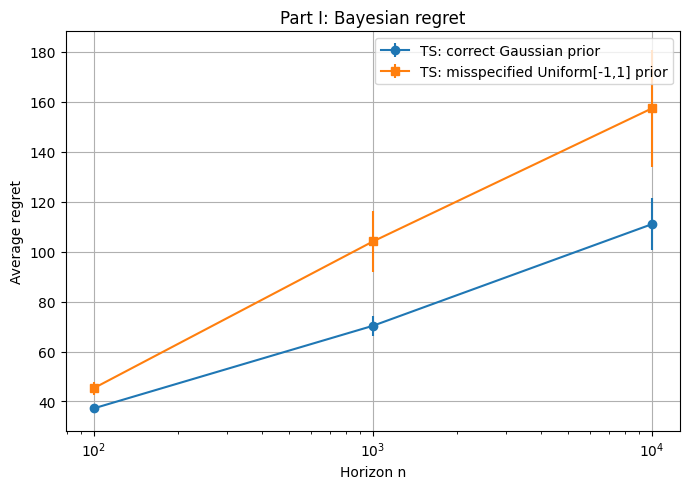

In [8]:
K = 10
horizons = [100, 1000, 10000]
num_sims_part1 = 50

tsg_avg, tsg_se = [], []
tsu_avg, tsu_se = [], []

for n in horizons:
    print(f"Running Part 1, n = {n}")
    avg, se = sim_random_mu(ts_gaussian, K, n, num_sims_part1, seed=123 + n)
    tsg_avg.append(avg)
    tsg_se.append(se)

    avg, se = sim_random_mu(ts_uniform, K, n, num_sims_part1, seed=456 + n)
    tsu_avg.append(avg)
    tsu_se.append(se)

tsg_avg = np.array(tsg_avg)
tsg_se = np.array(tsg_se)
tsu_avg = np.array(tsu_avg)
tsu_se = np.array(tsu_se)

plt.figure(figsize=(7, 5))
plt.errorbar(horizons, tsg_avg, yerr=tsg_se, marker='o', label='TS: correct Gaussian prior')
plt.errorbar(horizons, tsu_avg, yerr=tsu_se, marker='s', label='TS: misspecified Uniform[-1,1] prior')
plt.xscale('log')
plt.xlabel('Horizon n')
plt.ylabel('Average regret')
plt.title('Part I: Bayesian regret')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Running Part 2, delta = 0.05
Running Part 2, delta = 0.10
Running Part 2, delta = 0.15
Running Part 2, delta = 0.20
Running Part 2, delta = 0.25
Running Part 2, delta = 0.30
Running Part 2, delta = 0.35
Running Part 2, delta = 0.40
Running Part 2, delta = 0.45
Running Part 2, delta = 0.50
Running Part 2, delta = 0.55
Running Part 2, delta = 0.60
Running Part 2, delta = 0.65
Running Part 2, delta = 0.70
Running Part 2, delta = 0.75
Running Part 2, delta = 0.80
Running Part 2, delta = 0.85
Running Part 2, delta = 0.90
Running Part 2, delta = 0.95
Running Part 2, delta = 1.00


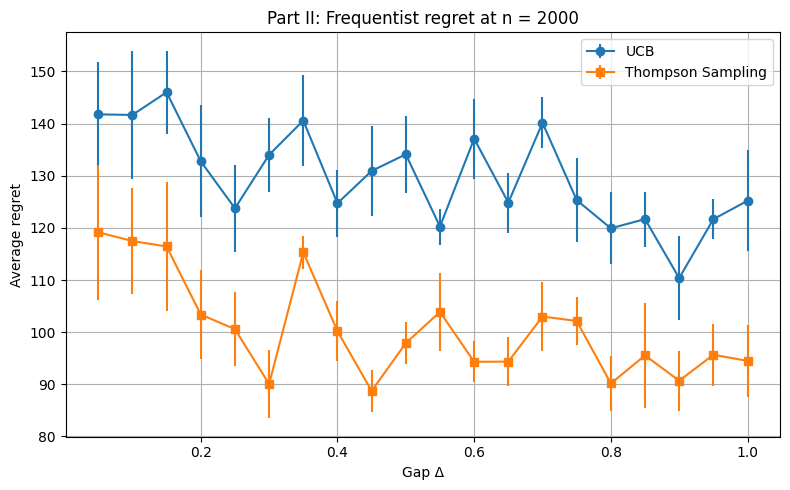

In [12]:
n_part2 = 2000
num_sims_part2 = 10
deltas = np.arange(0.05, 1.01, 0.05)

ucb_avg, ucb_se = [], []
ts_avg, ts_se = [], []

for delta in deltas:
    print(f"Running Part 2, delta = {delta:.2f}")
    mu = np.array([0.5, 0.5 - delta] + [-0.5] * 8)

    avg, se = sim_fixed_mu(ucb, mu, n_part2, num_sims_part2, seed=1000 + int(100 * delta))
    ucb_avg.append(avg)
    ucb_se.append(se)

    avg, se = sim_fixed_mu(ts_gaussian, mu, n_part2, num_sims_part2, seed=2000 + int(100 * delta))
    ts_avg.append(avg)
    ts_se.append(se)

ucb_avg = np.array(ucb_avg)
ucb_se = np.array(ucb_se)
ts_avg = np.array(ts_avg)
ts_se = np.array(ts_se)

plt.figure(figsize=(8, 5))
plt.errorbar(deltas, ucb_avg, yerr=ucb_se, marker='o', label='UCB')
plt.errorbar(deltas, ts_avg, yerr=ts_se, marker='s', label='Thompson Sampling')
plt.xlabel('Gap Δ')
plt.ylabel('Average regret')
plt.title('Part II: Frequentist regret at n = 2000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()